<a href="https://colab.research.google.com/github/sathwikdbhat/IOT-Class/blob/master/Machine_Learning_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Develop a program to create histograms for all numerical features and analyze the distribution of each feature. Generate box plots for all numerical features and identify any outliers. Use California Housing dataset.

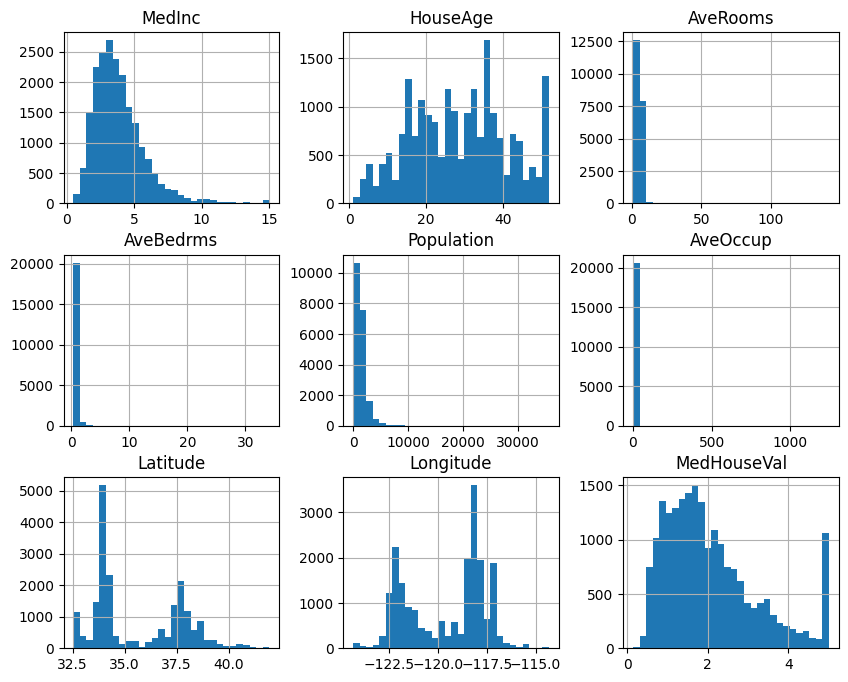

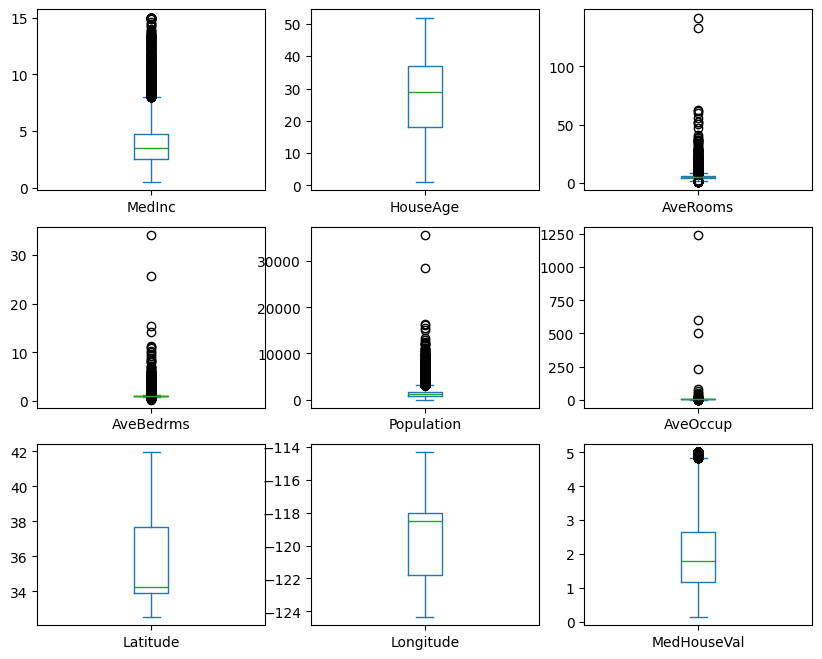


Outliers detected per feature:
MedInc         : 681
HouseAge       : 0
AveRooms       : 511
AveBedrms      : 1424
Population     : 1196
AveOccup       : 711
Latitude       : 0
Longitude      : 0
MedHouseVal    : 1071


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Load Data
df = fetch_california_housing(as_frame=True).frame

# 2. Histograms (Single command for all features)
df.hist(figsize=(10, 8), bins=30)
plt.show()

# 3. Box Plots (Single command for all features)
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(10,8))
plt.show()

# 4. Outlier Detection (IQR Method)
print("\nOutliers detected per feature:")
for c in df.columns:
    Q1, Q3 = df[c].quantile([.25, .75])
    IQR = Q3 - Q1
    # Count rows outside [Q1-1.5*IQR, Q3+1.5*IQR]
    out = df[(df[c] < Q1-1.5*IQR) | (df[c] > Q3+1.5*IQR)]
    print(f"{c:15}: {len(out)}")

2. Develop a program to Compute the correlation matrix to understand the relationships between pairs of features. Visualize the correlation matrix using a heatmap to know which variables have strong positive/negative correlations. Create a pair plot to visualize pairwise relationships between features. Use California Housing dataset.

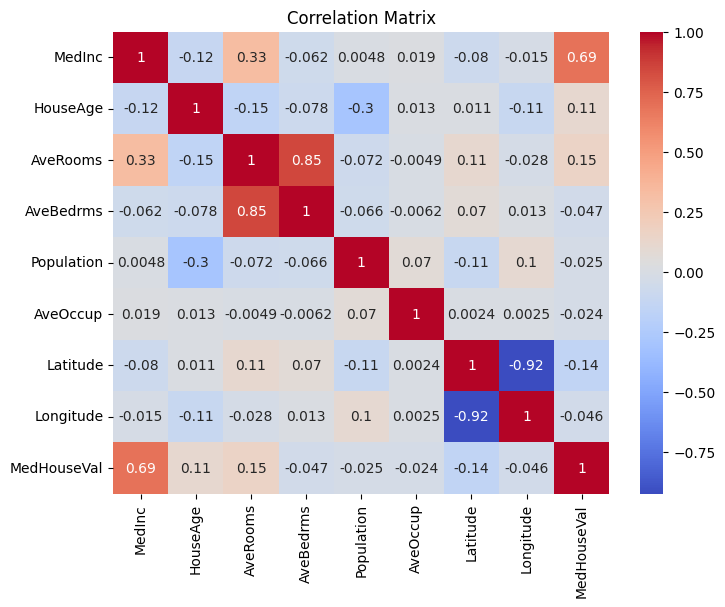

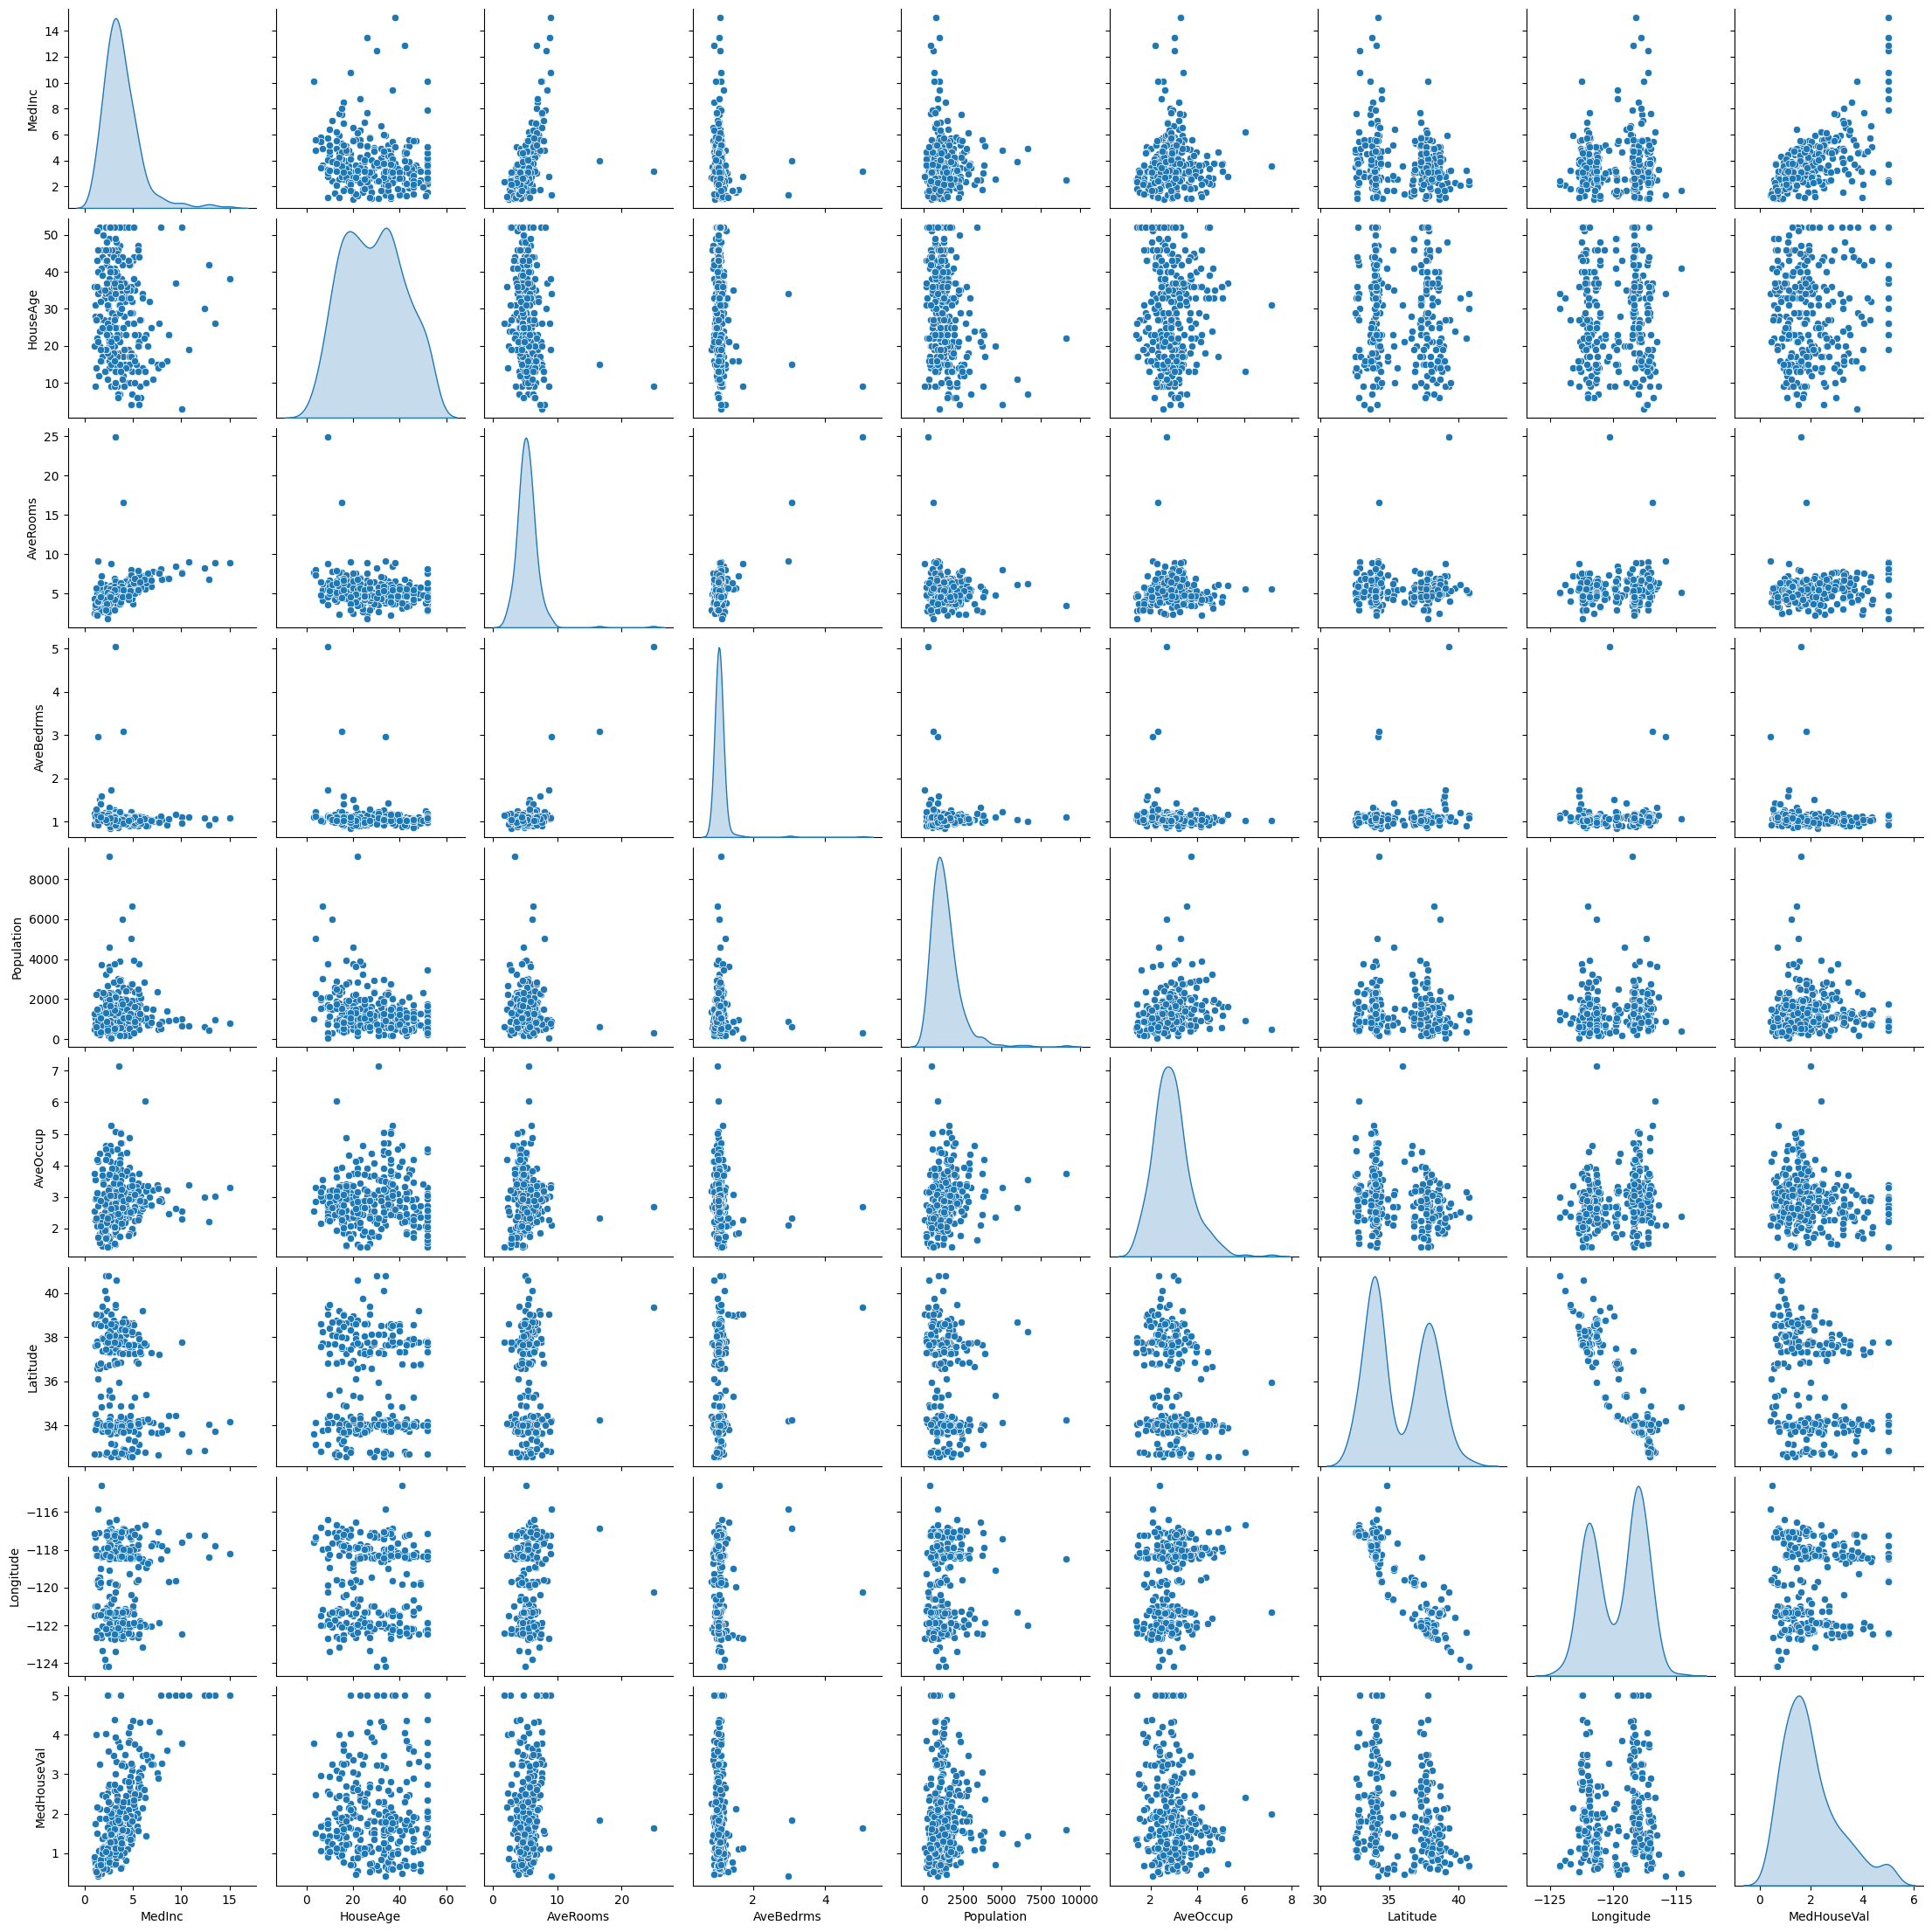

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Load Data
df = fetch_california_housing(as_frame=True).frame

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
# One-liner: calculate corr() and plot it
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 3. Pair Plot (Sampling 300 rows for maximum speed)
# Use a smaller sample to ensure it finishes in seconds
sns.pairplot(df.sample(300), diag_kind='kde')
plt.show()

3. Develop a program to implement Principal Component Analysis (PCA) for reducing the dimensionality of the Iris dataset from 4 features to 2.

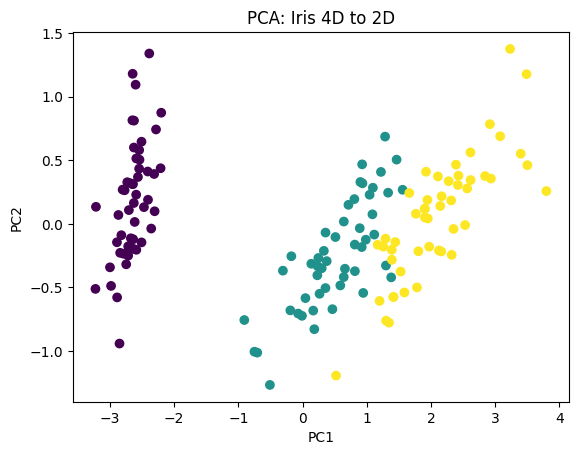

Variance Ratio: [0.92461872 0.05306648]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# 1. Load Data
iris = load_iris()
X, y = iris.data, iris.target

# 2. PCA: Reduce 4 features to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title("PCA: Iris 4D to 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# 4. Variance Explained (Crucial for Viva)
print("Variance Ratio:", pca.explained_variance_ratio_)

4. For a given set of training data examples stored in a .CSV file, implement and demonstrate the Find-S algorithm to output a description of the set of all hypotheses consistent with the training examples.

In [ ]:
import pandas as pd
import numpy as np

# 1. Load and display data
df = pd.read_csv('training_data.csv')
print("Training data:\n", df)

# 2. Extract features (X) and target (y)
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])

# 3. Initialize hypothesis with the first positive example
h = X[y == 'Yes'][0].copy()

# 4. Find-S Logic: Update for all positive examples
for x in X[y == 'Yes']:
    h[np.where(x != h)] = '?'

print(f"\nThe final hypothesis is: {list(h)}")

Training data:
     Outlook Temperature Humidity  Windy PlayTennis
0     Sunny         Hot     High  False         No
1     Sunny         Hot     High   True         No
2  Overcast         Hot     High  False        Yes
3      Rain        Cold     High  False        Yes
4      Rain        Cold     High   True         No
5  Overcast         Hot     High   True        Yes
6     Sunny         Hot     High  False         No

The final hypothesis is: ['?', '?', 'High', '?']


5. Develop a program to implement k-Nearest Neighbour algorithm to classify the randomly generated 100 values of x in the range of [0,1]. Perform the following based on dataset generated.
•	Label the first 50 points {x1,……,x50} as follows: if (xi ≤ 0.5), then xi ∊ Class1, else xi ∊ Class1
•	Classify the remaining points, x51,……,x100 using KNN. Perform this for k=1,2,3,4,5,20,30

k=1 | Class1: 25 | Class2: 25
k=3 | Class1: 24 | Class2: 26
k=5 | Class1: 24 | Class2: 26
k=20 | Class1: 24 | Class2: 26
k=30 | Class1: 25 | Class2: 25


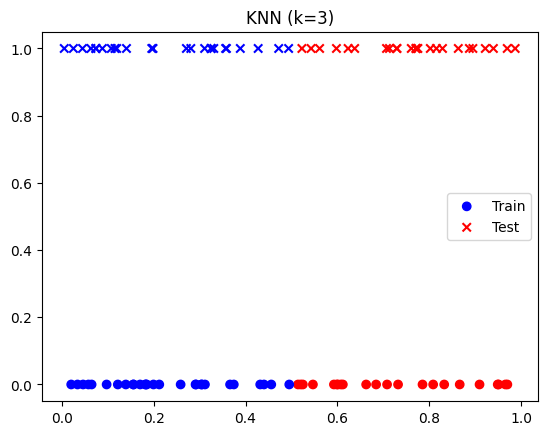

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Setup Data
np.random.seed(42)
x = np.random.rand(100)
tr_x, ts_x = x[:50], x[50:]
tr_y = ["Class1" if val <= 0.5 else "Class2" for val in tr_x]

# 2. KNN Logic & Output
for k in [1, 3, 5, 20, 30]:
    preds = []
    for p in ts_x:
        # One-liner: find k-nearest indices and their labels
        idx = np.argsort(np.abs(tr_x - p))[:k]
        lab = [tr_y[i] for i in idx]
        preds.append(Counter(lab).most_common(1)[0][0])

    print(f"k={k} | Class1: {preds.count('Class1')} | Class2: {preds.count('Class2')}")

# 3. Plotting (k=3 result)
plt.scatter(tr_x, [0]*50, c=['b' if l=='Class1' else 'r' for l in tr_y], label='Train')
plt.scatter(ts_x, [1]*50, c=['b' if l=='Class1' else 'r' for l in preds], marker='x', label='Test')
plt.legend(); plt.title("KNN (k=3)"); plt.show()

6. Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs.

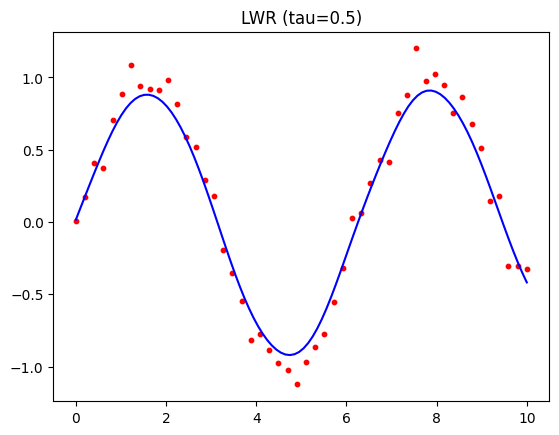

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Generation (Sine Wave)
X = np.linspace(0, 10, 50)
y = np.sin(X) + np.random.normal(0, 0.1, 50)
X_mat = np.c_[np.ones(50), X] # Add bias column

# 2. LWR Logic
def lwr_point(x_pt, X, y, tau):
    # Gaussian Kernel weights
    weights = np.exp(-np.sum((X - x_pt)**2, axis=1) / (2 * tau**2))
    W = np.diag(weights)
    # Weighted Normal Equation: (X.T * W * X)^-1 * (X.T * W * y)
    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)
    return x_pt @ theta

# 3. Prediction & Plot
tau = 0.5
x_test = np.linspace(0, 10, 100)
preds = [lwr_point([1, val], X_mat, y, tau) for val in x_test]

plt.scatter(X, y, c='red', s=10)
plt.plot(x_test, preds, c='blue')
plt.title(f"LWR (tau={tau})"); plt.show()

7. Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use Boston Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial Regression.

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15274/1916549983.py:19: SyntaxWarning: invalid escape sequence '\s'
  df_a = pd.read_csv(url, sep='\s+', names=cols, na_values="?").dropna()


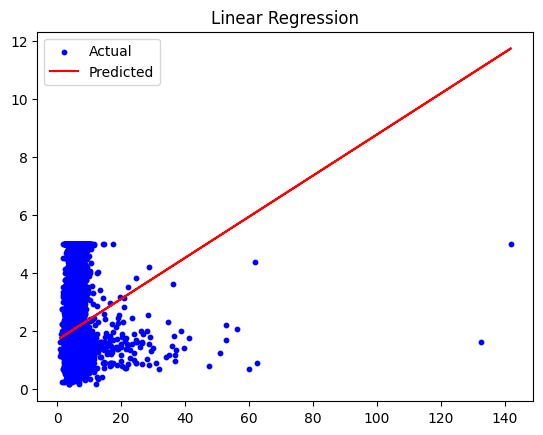

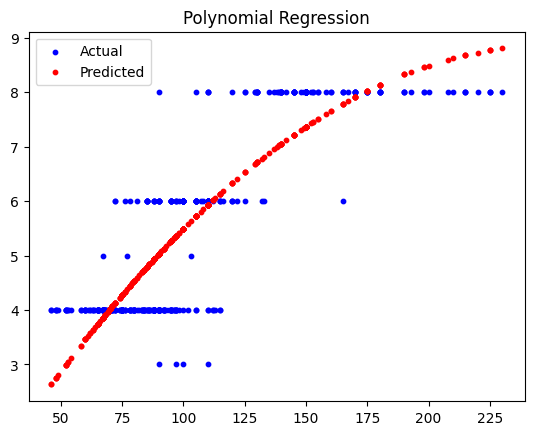

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing

# 1. Linear Regression (California Housing)
df_cal = fetch_california_housing(as_frame=True).frame
X_l, y_l = df_cal[['AveRooms']], df_cal['MedHouseVal']
model_l = LinearRegression().fit(X_l, y_l)

plt.scatter(X_l, y_l, s=10, c='b', label='Actual')
plt.plot(X_l, model_l.predict(X_l), c='r', label='Predicted')
plt.title("Linear Regression"); plt.legend(); plt.show()

# 2. Polynomial Regression (Auto MPG)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
cols = ["mpg", "c", "disp", "hp", "wt", "acc", "yr", "orig"]
df_a = pd.read_csv(url, sep='\s+', names=cols, na_values="?").dropna()
X_p, y_p = df_a[['disp']], df_a['mpg']

# Transform and Fit Degree 2
X_p2 = PolynomialFeatures(degree=2).fit_transform(X_p)
model_p = LinearRegression().fit(X_p2, y_p)

plt.scatter(X_p, y_p, s=10, c='b', label='Actual')
plt.scatter(X_p, model_p.predict(X_p2), s=10, c='r', label='Predicted')
plt.title("Polynomial Regression"); plt.legend(); plt.show()

8. Develop a program to demonstrate the working of the decision tree algorithm. Use Breast Cancer Data set for building the decision tree and apply this knowledge to classify a new sample.

Prediction: malignant


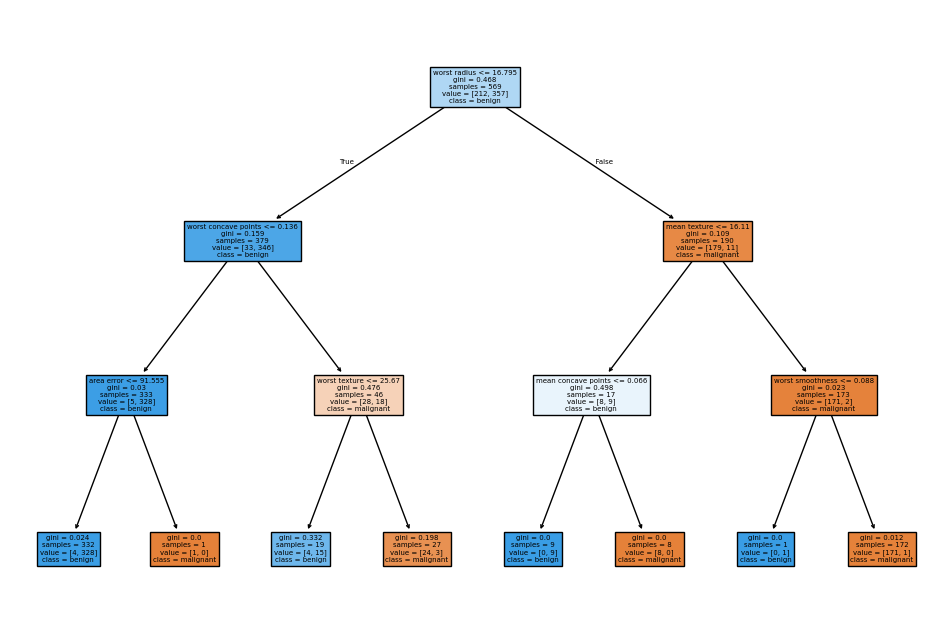

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load Data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# 2. Build Tree (Depth=3 is best for visualization)
clf = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X, y)

# 3. Predict a new sample (using the first row)
pred = clf.predict(X[:1])
print(f"Prediction: {cancer.target_names[pred[0]]}")

# 4. Visualize the Tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=cancer.feature_names, class_names=cancer.target_names, filled=True)
plt.show()

9. Develop a program to implement the Naive Bayesian classifier considering Olivetti Face Data set for training. Compute the accuracy of the classifier, considering a few test data sets.

Accuracy: 77.50%


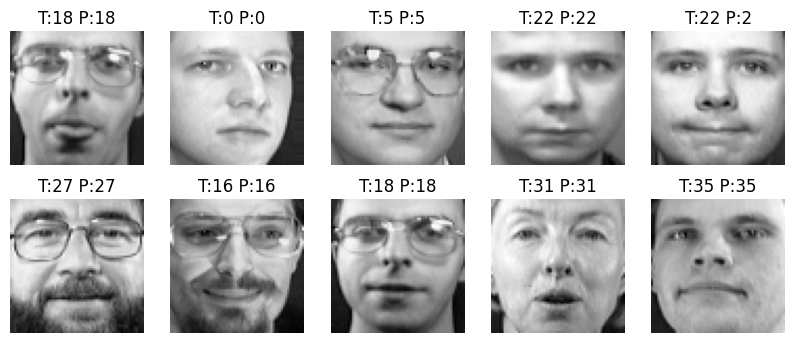

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. Load and Split Data
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = faces.data, faces.target
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Naive Bayes
model = GaussianNB().fit(X_tr, y_tr)
preds = model.predict(X_ts)

# 3. Accuracy and Visualization
print(f"Accuracy: {model.score(X_ts, y_ts)*100:.2f}%")

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_ts[i].reshape(64, 64), cmap='gray')
    plt.title(f"T:{y_ts[i]} P:{preds[i]}")
    plt.axis('off')
plt.show()

10.	Develop a program to implement k-means clustering using Wisconsin Breast Cancer data set and visualize the clustering result.

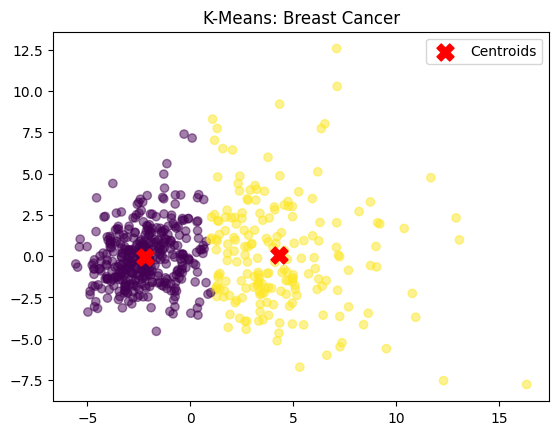

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load and Scale
cancer = load_breast_cancer()
X_sc = StandardScaler().fit_transform(cancer.data)

# 2. K-Means (Unsupervised Clustering)
km = KMeans(n_clusters=2, n_init=10, random_state=42)
y_km = km.fit_predict(X_sc)

# 3. PCA for 2D Plotting
pca = PCA(n_components=2)
X_p = pca.fit_transform(X_sc)
# Transform centers to the same 2D space
ctr = pca.transform(km.cluster_centers_)

# 4. Visualization
plt.scatter(X_p[:, 0], X_p[:, 1], c=y_km, alpha=0.5)
plt.scatter(ctr[:, 0], ctr[:, 1], c='red', marker='X', s=150, label='Centroids')
plt.title("K-Means: Breast Cancer"); plt.legend(); plt.show()